# Satellite Image Classification Demo

This notebook demonstrates how to use the satellite image classification utilities for comparing multiple pretrained models on satellite imagery.

## Setup and Import

In [ ]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from satellite_classifier import classify_satellite_image, visualize_comparison, export_results
from satellite_classifier.widgets import quick_load_models, create_model_selector

## Step 1: Load Pre-trained Models

In [2]:
# Create an instance of the model selector widget
# This will allow users to select models for classification tasks
modelSelector = create_model_selector()

NameError: name 'create_model_selector' is not defined

## Step 2: Classify Satellite Images
You can use a local path or a URL (replace the example with a real satellite image URL if you have one)

**Make sure the URL is directly linkable to an image file (e.g., .jpg, .png)**

In [ ]:
models = modelSelector.get_loaded_models()
# Classify an image (example with a local satellite image)
# If using a local file:
# image_path = "../data/example_images/your_satellite_image.jpg"
image_path = '../data/test_4.png' 
if not os.path.exists(image_path):
    raise FileNotFoundError(f"Image not found: {image_path}")

print(f"\nClassifying image: {image_path}")
results = classify_satellite_image(models, image_path)

# Print summary of results
print(f"\nClassification completed!")
print(f"Models processed: {len(results)}")
for model_name, result in results.items():
    if 'error' not in result:
        top_prediction = result['predictions'][0]
        print(f"  {model_name}: {top_prediction['class']} ({top_prediction['confidence']:.3f})")
    else:
        print(f"  {model_name}: Error - {result['error']}")


Classifying image: ../data/test_4.png
✓ Loaded image: (1536, 1408)
✓ Classification completed for resnet18 (10 classes)
✓ Classification completed for resnet50 (10 classes)

Classification completed!
Models processed: 2
  resnet18: Unknown (0.002)
  resnet50: Unknown (0.000)


## Step 3: Visualize Comparison Results

How to interpret the results:
- Each model's top prediction is displayed along with its confidence score.
- If a model fails to classify the image, an error message is shown instead.

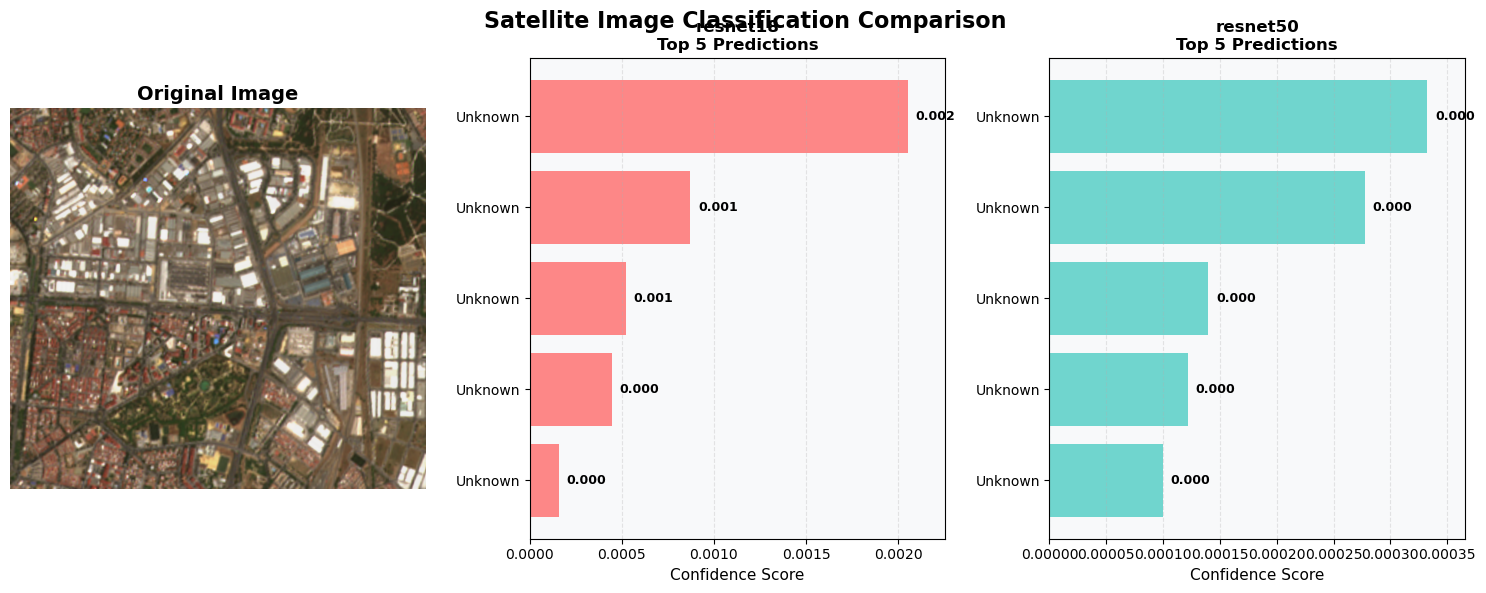

In [4]:
visualize_comparison(image_path, results, "Satellite Image Classification Comparison")

## Step 4: Model Performance Summary and export

This last step provides a summary of the models processed and their classification results. It includes the number of models processed and a detailed output for each model's predictions.

In [ ]:
# Display detailed results for analysis
def print_detailed_results(results, image_name):
    """Print detailed classification results for analysis"""
    print(f"\n{'='*60}")
    print(f"DETAILED RESULTS FOR: {image_name}")
    print(f"{'='*60}")
    
    for model_name, result in results.items():
        print(f"\n🤖 {model_name}")
        print("-" * 40)
        
        if 'error' in result:
            print(f"❌ Error: {result['error']}")
            continue
            
        print(f"Number of classes: {result['num_classes']}")
        print("Top 5 predictions:")
        
        for i, pred in enumerate(result['predictions'][:5], 1):
            bar_length = int(pred['confidence'] * 30)
            confidence_bar = "█" * bar_length + "░" * (30 - bar_length)
            print(f"  {i}. {pred['class']:<25} {pred['confidence']:.4f} │{confidence_bar}│")

# Show detailed results for the first image
print_detailed_results(results, image_path)

In [ ]:
# Save results to a text file for further analysis
export_results(mode='json', results=results, output_dir='../results')
print("Results exported to ../results")